# VaLPAS - Notebook to demonstrate usage of the API and show different features of the code.

VaLPAS (***Va***riation-***L***everaged ***P***henomic ***A***ssoccioation ***S***tudy) is a toolkit with the ultimate purpose to iluminate the biological dark matter by providing a systemic framework to predict protein functionality from phenomics. VaLPAS uses phenotypic variation between organisms as well as various modes of omics-data (e.g. Proteomics, Metabolomics, Transcriptomics, etc.) collected under differing environmental conditions. The toolkit generates associations between the different datatypes that then can be leveraged to postulate hypothesis of protein functionality for proteins of previously unknown function.

VaLPAS (`valpas.py`) can be either executed from the command line or used from within a Jupyter Notebook (like this one) using the VaLPAS API which is preferred, since currently there are more options available to the user through the API. Currently VaLPAS' two main subroutines (commands) are to:
- generate said associations (`associate`)
- visualize association strenghts for further investigation (`visualize`)

## Dependencies
Dependencies to run this notebook should be installed according to the README.md located at the root folder of the project. Requirements/dependencies are presented in the requirements.txt, which can be used to establish an environment using venv (see README for directions).

## Dependencies & Imports

In [9]:
from pathlib import Path
import os
from IPython.core.display import HTML

import valpas
# Import necessary modules
from valpas.valpas_core import associate, prepare, visualize
from valpas.visualization.graph_visualization import InteractiveGraphVisualizer
from valpas.visualization.edge_venn_diagram_plot import plot_network_venn_diagrams

# don't show warnings
import warnings
warnings.filterwarnings('ignore')

## VaLPAS protein association generation from proteomics

Need to execute VaLPAS to generate output files (unless they already exist) from Rhodosporidium proteomics data.
In the same loop we will create edgelists that have mapped KO ids and then evaluate.

In [10]:
rt_fpath_protein_xlsx = Path("../sample_data/rhodo_data/Rhodo_Multi.xlsx")

results = {}

methods = ["pearson", "spearman", "cosine_similarity"]
for this in methods:
    fpath_out = f"../sample_data/rhodo_data/demo_rhodo_prot-prot_assoc_mat_{this}.csv.gz"

    # Example: Generating associations between proteomics data points
    print(f"Generating VaLPAS for {this} to output to {fpath_out}")
    
    association_result = associate(
        association_type=this,          # Type of association metric
        infile=rt_fpath_protein_xlsx,        # Input file
        file_type="xlsx", 
        sheet="Proteomics",
        annotation_file='../sample_data/rhodo_data/Rhodo_annotation.tsv',
        report_file=f'../sample_data/rhodo_data/demo_rhodo_prot-prot_assoc_mat_{this}_report.txt',
        annotation_args={'primary_id_column':'protein', 'primary_annotation_column':'extra'},
        filter_cutoff=0.5,                   # Filter cutoff for missing values
        output_type="sorted_list",           # Output format
        outfile=fpath_out  # Path for saving the result
    )
    results[this] = association_result

Generating VaLPAS for pearson to output to ../sample_data/rhodo_data/demo_rhodo_prot-prot_assoc_mat_pearson.csv.gz
Reading annotation file: ../sample_data/rhodo_data/Rhodo_annotation.tsv
Detected file type: .tsv
Auto-detected delimiter: '	' (found 5 occurrences)
Successfully read file with shape: (6540, 6)
Columns found: ['pc1', 'pc2', 'protein', 'pc4', 'ko', 'extra']

ANNOTATION FILE VALIDATION SUMMARY
File: ../sample_data/rhodo_data/Rhodo_annotation.tsv
File size: 0.29 MB
Final shape: (6540, 2)

Processing Summary:
  Rows processed: 6540
  Columns retained: 2
  Unique primary IDs: 6540
  Non-null annotations: 3105

ID Quality:
  Total IDs: 6540
  Unique IDs: 6540
  Duplicates: 0
  Missing IDs: 0

Annotation Quality:
  Unique annotations: 2676
  Diversity ratio: 0.862

Validation Status: ✓ SUCCESS
Generating VaLPAS for spearman to output to ../sample_data/rhodo_data/demo_rhodo_prot-prot_assoc_mat_spearman.csv.gz
Reading annotation file: ../sample_data/rhodo_data/Rhodo_annotation.tsv
D

Rank,Protein 1,Protein 2,Weight,Count,Confidence,Annotation 1,Annotation 2,Ann. Status
1,12060,10696,1.000000,11.0,1.0000,"ERK, MAPK1_3; mitogen-activated protein kinase 1/3 [EC:2.7.11.24]",N/A,One annotated
2,9231,8598,1.000000,11.0,1.0000,H4; histone H4,N/A,One annotated
3,9231,8615,1.000000,11.0,1.0000,H4; histone H4,H4; histone H4,Both annotated
4,9231,8624,1.000000,11.0,1.0000,H4; histone H4,H4; histone H4,Both annotated
5,9232,8629,1.000000,11.0,1.0000,N/A,N/A,Neither annotated
6,8598,8615,1.000000,11.0,1.0000,N/A,H4; histone H4,One annotated
7,8598,8624,1.000000,11.0,1.0000,N/A,H4; histone H4,One annotated
8,8882,13643,1.000000,10.0,1.0000,"UBE2D, UBC4, UBC5; ubiquitin-conjugating enzyme E2 D [EC:2.3.2.23]","UBE2C, UBC11; ubiquitin-conjugating enzyme E2 C [EC:2.3.2.23]",Both annotated
9,15155,15142,1.000000,11.0,1.0000,N/A,N/A,Neither annotated
10,16557,9119,1.000000,4.0,1.0000,N/A,N/A,Neither annotated

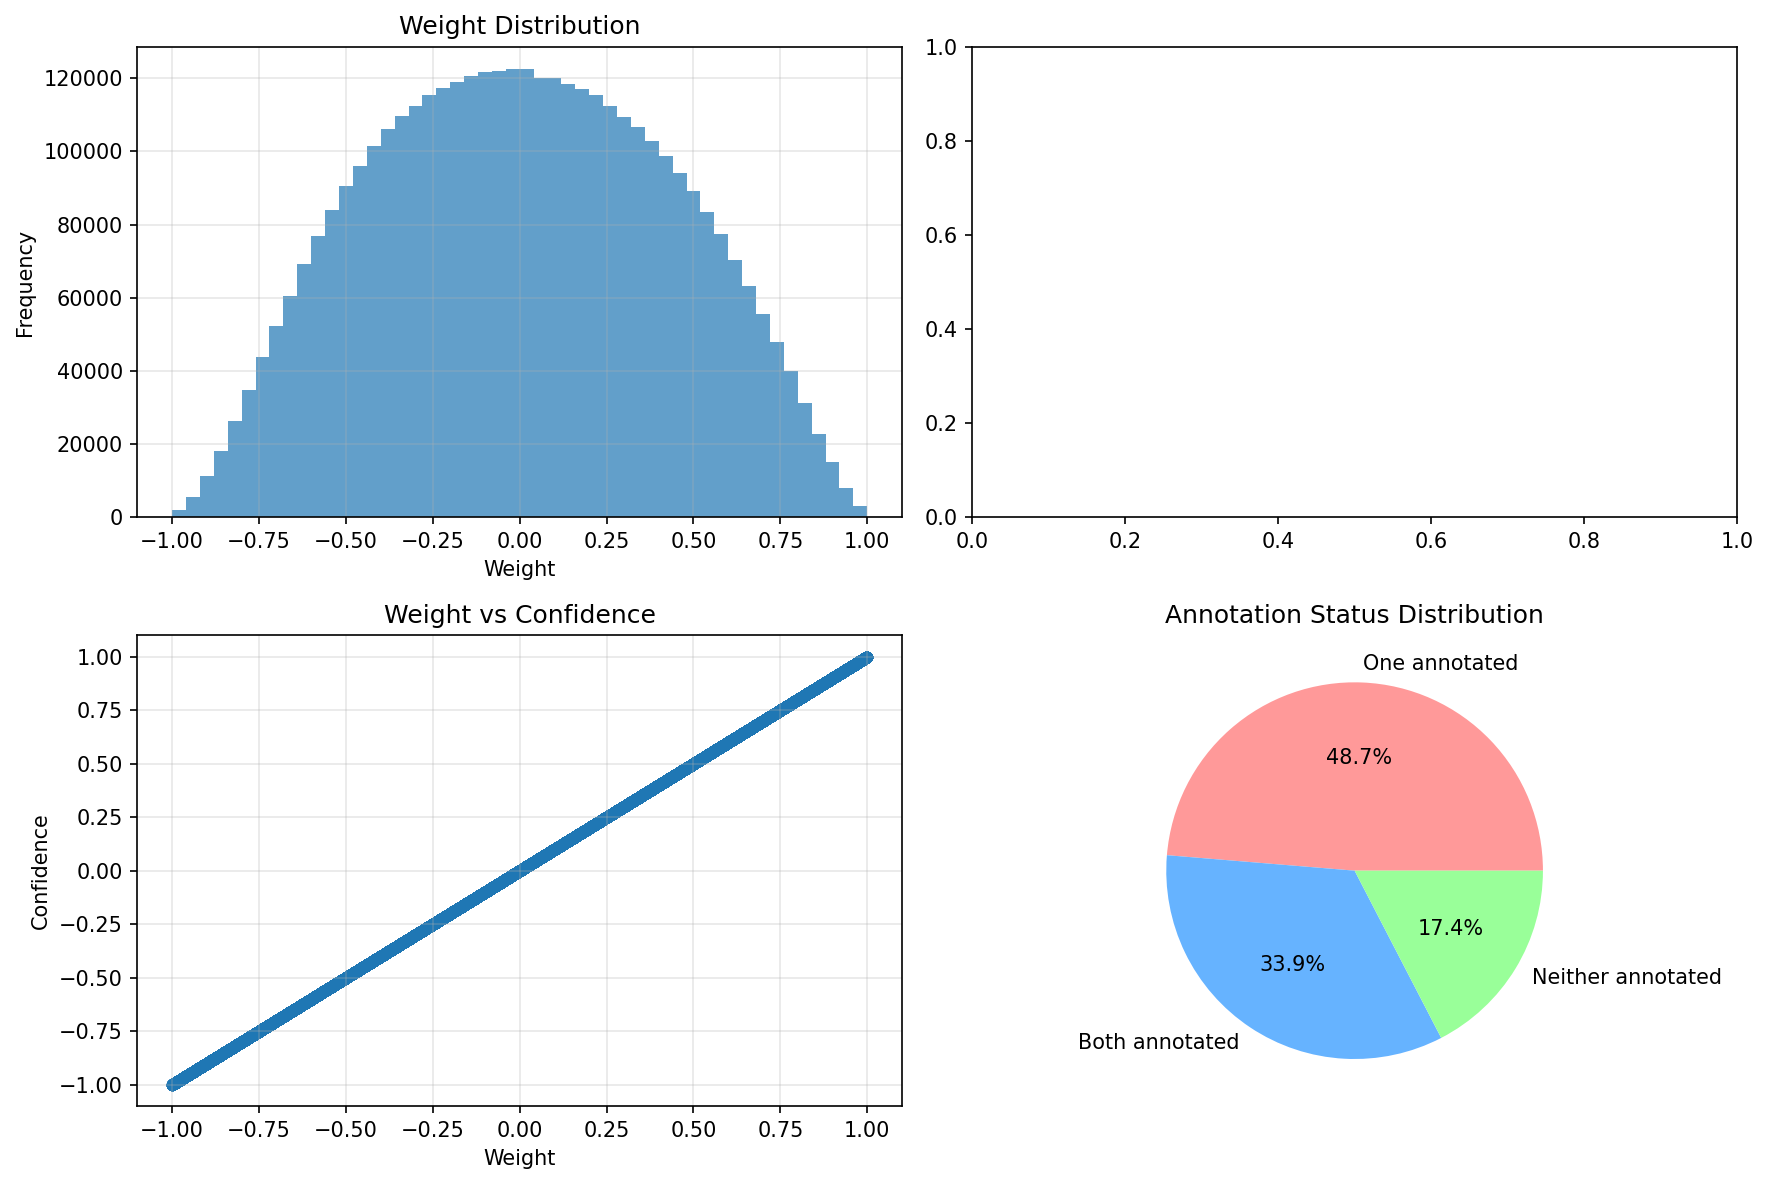

In [11]:
HTML(results['pearson'].generate_report(weight_col='correlation', confidence_col='correlation', top_n=500, include_statistics=False)[0])

In [17]:
visualizer = InteractiveGraphVisualizer(
        data=results['pearson'].edgelist.head(500),
        source_col='Proteomics_1',
        target_col='Proteomics_2',
        weight_col='correlation',
        confidence_col='correlation',
        source_annotation_col='extra_x',
        target_annotation_col='extra_y',
        edge_annotation_col='connection_type'
    )

import plotly.io as pio
pio.renderers.default = "notebook"  # or "colab" if using Google Colab

visualizer.print_color_legend()
visualizer.interactive_widget()

Annotated Neighbors Color Scheme:
🔵 Cyan: Nodes with annotations
🔴 Red: Non-annotated nodes with 0 annotated neighbors
🟠 Orange: Non-annotated nodes with 1 annotated neighbor
🟢 Green: Non-annotated nodes with 2 annotated neighbors
🔵 Blue: Non-annotated nodes with 3 annotated neighbors
🟣 Purple: Non-annotated nodes with 4 annotated neighbors
🟤 Brown: Non-annotated nodes with 5 annotated neighbors
🩷 Pink: Non-annotated nodes with 6+ annotated neighbors

Hover Tips:
📋 = Node's own annotation
📝 = Annotated neighbors with their annotations
📄 = Non-annotated neighbors (names only)
🔗 = Connection summary


interactive(children=(FloatSlider(value=0.9928108733649675, description='Min correlation:', max=1.0, min=0.992…

Figure saved to: ../sample_data/rhodo_data/venn_diagram.png


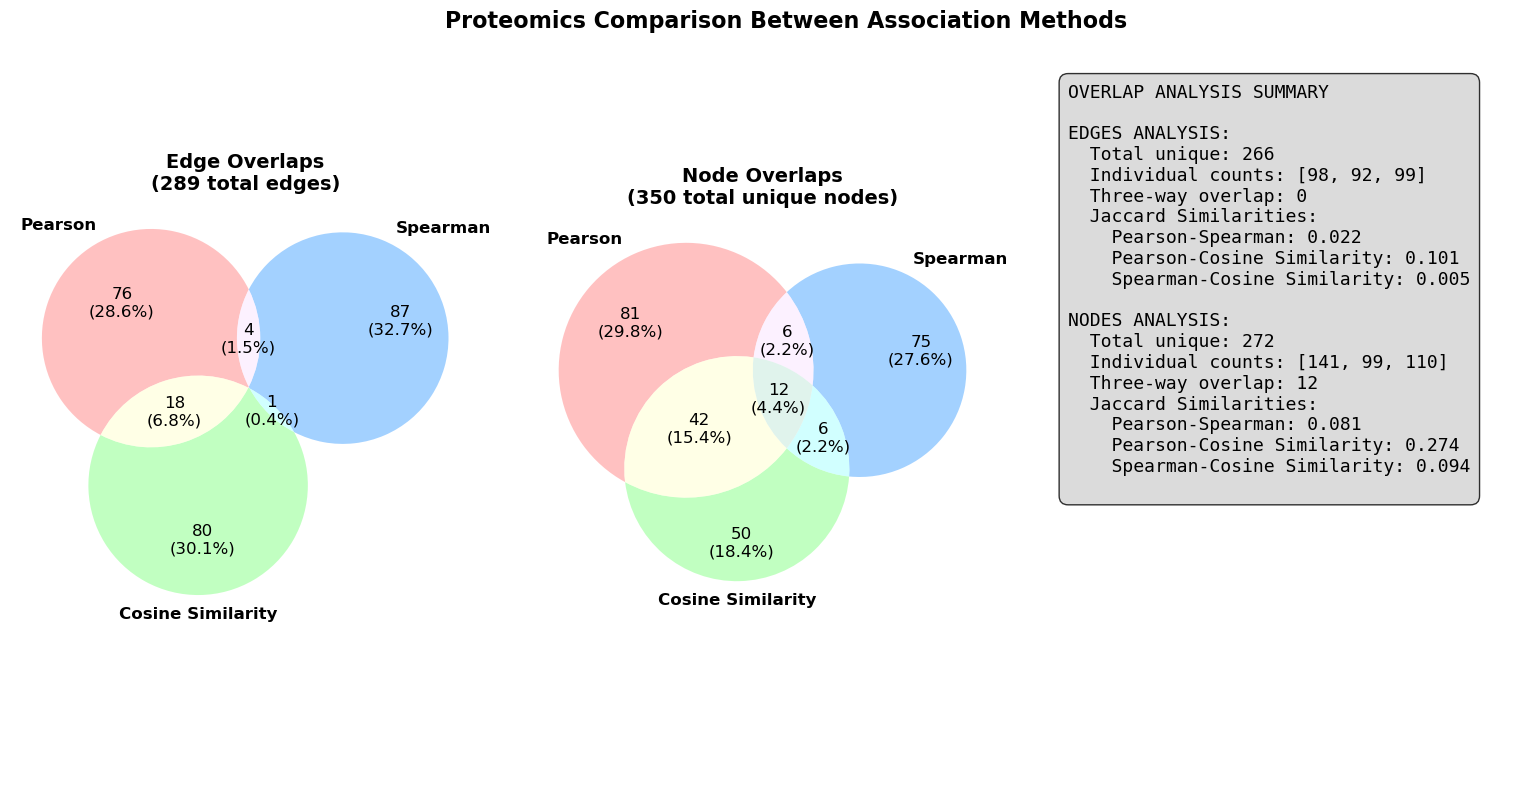

In [18]:
fig, analysis = plot_network_venn_diagrams(
    dataframes=[results['pearson'].edgelist.head(100), 
                results['spearman'].edgelist.head(100),
                results['cosine_similarity'].edgelist.head(100)],
    protein1_col = 'protein_x',
    protein2_col = 'protein_y',
    labels=['Pearson', 'Spearman', 'Cosine Similarity'],
    title='Proteomics Comparison Between Association Methods',
    save_path='../sample_data/rhodo_data/venn_diagram.png'
)

In [19]:
analysis

{'edges': {'element_type': 'edges',
  'labels': ['Pearson', 'Spearman', 'Cosine Similarity'],
  'set_sizes': [98, 92, 99],
  'A': {('10036', '14700'),
   ('10038', '13121'),
   ('10038', 'nan'),
   ('10101', '15717'),
   ('10101', '16652'),
   ('10224', '16779'),
   ('10509', '15763'),
   ('10561', '11552'),
   ('10561', '16428'),
   ('10582', '16000'),
   ('10696', '12060'),
   ('10706', '11152'),
   ('10706', '15873'),
   ('10916', '12855'),
   ('10917', '13320'),
   ('11143', '12562'),
   ('11252', '8694'),
   ('11308', '15732'),
   ('11412', '16587'),
   ('11454', '16266'),
   ('11522', '15699'),
   ('11704', 'nan'),
   ('11718', '15776'),
   ('11724', '13232'),
   ('11828', '16266'),
   ('11847', '9982'),
   ('11924', '14909'),
   ('11940', '13745'),
   ('11947', '8694'),
   ('11974', '14762'),
   ('12095', '16856'),
   ('12147', '13399'),
   ('12147', '9111'),
   ('12147', 'nan'),
   ('12159', '14056'),
   ('12159', '16159'),
   ('12159', '16411'),
   ('12175', 'nan'),
   ('12228